In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import time
import os

DATASET_FOLDER = r"C:\Users\K KIRAN KUMAR\OneDrive\DL_verse\Dataset_v2"

X_train = np.load(os.path.join(DATASET_FOLDER, "X_train.npy"))
y_train = np.load(os.path.join(DATASET_FOLDER, "y_train.npy"))
X_test  = np.load(os.path.join(DATASET_FOLDER, "X_test.npy"))
y_test  = np.load(os.path.join(DATASET_FOLDER, "y_test.npy"))

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (171104, 81)
y_train : (171104,)
X_test  : (63348, 81)
y_test  : (63348,)


In [2]:
# Scale features
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)

# Balance dataset
X_pos = X_train_sc[y_train == 1]
X_neg = X_train_sc[y_train == 0]
y_pos = y_train[y_train == 1]
y_neg = y_train[y_train == 0]

X_pos_up, y_pos_up = resample(X_pos, y_pos,
                               replace=True,
                               n_samples=len(X_neg),
                               random_state=42)

X_balanced = np.vstack([X_neg, X_pos_up])
y_balanced  = np.concatenate([y_neg, y_pos_up])

print(f"Balanced dataset : {len(y_balanced)} samples")
print(f"Positives        : {np.sum(y_balanced==1)}")
print(f"Negatives        : {np.sum(y_balanced==0)}")

Balanced dataset : 256656 samples
Positives        : 128328
Negatives        : 128328


In [3]:
print("Training Single Layer Perceptron...")
print("="*40)

slp = MLPClassifier(
    hidden_layer_sizes=(),
    activation='logistic',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=100,
    batch_size=256,
    random_state=42,
    verbose=False
)

start = time.time()
slp.fit(X_balanced, y_balanced)
end   = time.time()

y_pred_slp = slp.predict(X_test_sc)
acc        = accuracy_score(y_test, y_pred_slp)
report     = classification_report(y_test, y_pred_slp,
                                   target_names=["No Node","Node"],
                                   output_dict=True,
                                   zero_division=0)

print(f"Training time  : {end-start:.2f}s")
print(f"Accuracy       : {acc*100:.2f}%")
print(f"Node Precision : {report['Node']['precision']*100:.2f}%")
print(f"Node Recall    : {report['Node']['recall']*100:.2f}%")
print(f"F1 Score       : {report['Node']['f1-score']*100:.2f}%")

Training Single Layer Perceptron...
Training time  : 18.65s
Accuracy       : 61.64%
Node Precision : 32.70%
Node Recall    : 50.48%
F1 Score       : 39.69%


In [4]:
print("Training MLP 3x3 Double Layer...")
print("="*40)

mlp_3x3 = MLPClassifier(
    hidden_layer_sizes=(9, 9),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=200,
    batch_size=256,
    random_state=42,
    verbose=False
)

start = time.time()
mlp_3x3.fit(X_balanced, y_balanced)
end   = time.time()

y_pred_3x3 = mlp_3x3.predict(X_test_sc)
acc         = accuracy_score(y_test, y_pred_3x3)
report      = classification_report(y_test, y_pred_3x3,
                                    target_names=["No Node","Node"],
                                    output_dict=True,
                                    zero_division=0)

print(f"Training time  : {end-start:.2f}s")
print(f"Accuracy       : {acc*100:.2f}%")
print(f"Node Precision : {report['Node']['precision']*100:.2f}%")
print(f"Node Recall    : {report['Node']['recall']*100:.2f}%")
print(f"F1 Score       : {report['Node']['f1-score']*100:.2f}%")

Training MLP 3x3 Double Layer...
Training time  : 149.00s
Accuracy       : 73.45%
Node Precision : 48.20%
Node Recall    : 83.00%
F1 Score       : 60.98%


In [5]:
print("Training MLP 5x5 Double Layer...")
print("="*40)

mlp_5x5 = MLPClassifier(
    hidden_layer_sizes=(25, 25),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=200,
    batch_size=256,
    random_state=42,
    verbose=False
)

start = time.time()
mlp_5x5.fit(X_balanced, y_balanced)
end   = time.time()

y_pred_5x5 = mlp_5x5.predict(X_test_sc)
acc         = accuracy_score(y_test, y_pred_5x5)
report      = classification_report(y_test, y_pred_5x5,
                                    target_names=["No Node","Node"],
                                    output_dict=True,
                                    zero_division=0)

print(f"Training time  : {end-start:.2f}s")
print(f"Accuracy       : {acc*100:.2f}%")
print(f"Node Precision : {report['Node']['precision']*100:.2f}%")
print(f"Node Recall    : {report['Node']['recall']*100:.2f}%")
print(f"F1 Score       : {report['Node']['f1-score']*100:.2f}%")

Training MLP 5x5 Double Layer...
Training time  : 495.50s
Accuracy       : 75.63%
Node Precision : 50.76%
Node Recall    : 83.63%
F1 Score       : 63.18%


In [6]:
print("Training MLP 9x9 Double Layer...")
print("="*40)

mlp_9x9 = MLPClassifier(
    hidden_layer_sizes=(81, 81),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=200,
    batch_size=256,
    random_state=42,
    verbose=False
)

start = time.time()
mlp_9x9.fit(X_balanced, y_balanced)
end   = time.time()

y_pred_9x9 = mlp_9x9.predict(X_test_sc)
acc         = accuracy_score(y_test, y_pred_9x9)
report      = classification_report(y_test, y_pred_9x9,
                                    target_names=["No Node","Node"],
                                    output_dict=True,
                                    zero_division=0)

print(f"Training time  : {end-start:.2f}s")
print(f"Accuracy       : {acc*100:.2f}%")
print(f"Node Precision : {report['Node']['precision']*100:.2f}%")
print(f"Node Recall    : {report['Node']['recall']*100:.2f}%")
print(f"F1 Score       : {report['Node']['f1-score']*100:.2f}%")

Training MLP 9x9 Double Layer...


C:\Users\K KIRAN KUMAR\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Training time  : 1190.19s
Accuracy       : 76.90%
Node Precision : 52.65%
Node Recall    : 75.42%
F1 Score       : 62.01%


In [7]:
models = {
    "SLP"          : (slp,     y_pred_slp),
    "MLP 3x3"      : (mlp_3x3, y_pred_3x3),
    "MLP 5x5"      : (mlp_5x5, y_pred_5x5),
    "MLP 9x9"      : (mlp_9x9, y_pred_9x9),
}

print(f"\n{'Model':<15} {'Accuracy':>10} {'Precision':>12} "
      f"{'Recall':>10} {'F1':>8}")
print("-"*58)

for name, (model, y_pred) in models.items():
    acc    = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                   target_names=["No Node","Node"],
                                   output_dict=True,
                                   zero_division=0)
    prec = report["Node"]["precision"]
    rec  = report["Node"]["recall"]
    f1   = report["Node"]["f1-score"]

    print(f"{name:<15} {acc*100:>9.2f}% {prec*100:>11.2f}% "
          f"{rec*100:>9.2f}% {f1*100:>7.2f}%")

print("-"*58)
print(f"{'CNN (from nb2)':<15} {'75.22%':>10} {'50.27%':>12} "
      f"{'82.31%':>10} {'62.42%':>8}")


Model             Accuracy    Precision     Recall       F1
----------------------------------------------------------
SLP                 61.64%       32.70%     50.48%   39.69%
MLP 3x3             73.45%       48.20%     83.00%   60.98%
MLP 5x5             75.63%       50.76%     83.63%   63.18%
MLP 9x9             76.90%       52.65%     75.42%   62.01%
----------------------------------------------------------
CNN (from nb2)      75.22%       50.27%     82.31%   62.42%


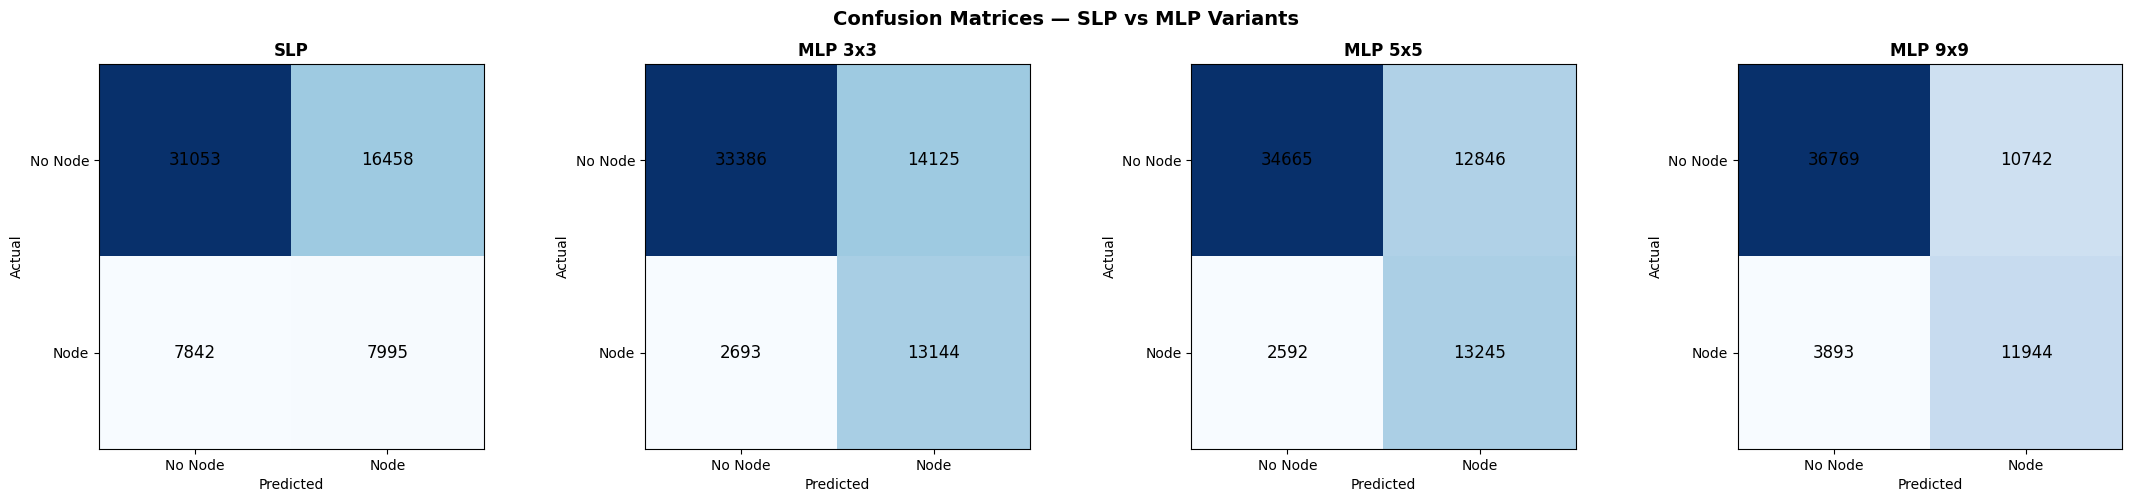

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

model_preds = {
    "SLP"     : y_pred_slp,
    "MLP 3x3" : y_pred_3x3,
    "MLP 5x5" : y_pred_5x5,
    "MLP 9x9" : y_pred_9x9,
}

for ax, (name, y_pred) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    ax.imshow(cm, cmap='Blues')
    ax.set_title(f"{name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["No Node","Node"])
    ax.set_yticklabels(["No Node","Node"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]),
                   ha='center', va='center',
                   color='black', fontsize=12)

plt.suptitle("Confusion Matrices — SLP vs MLP Variants",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

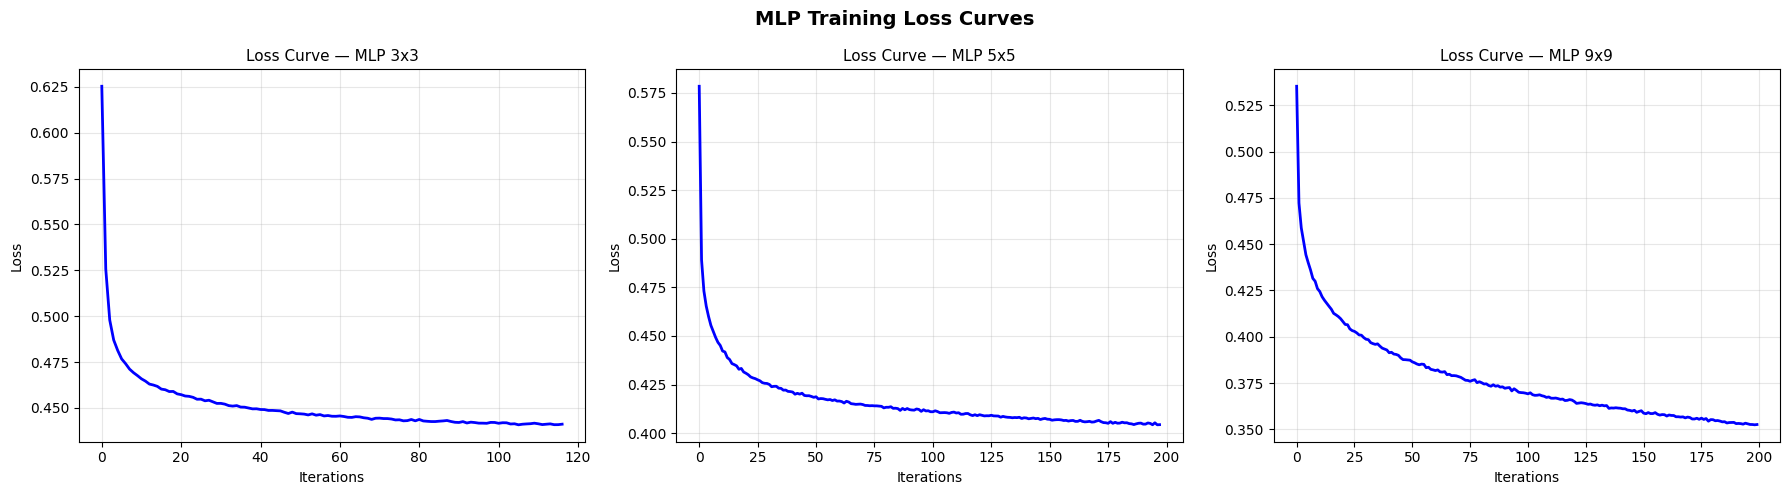

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mlp_models = {
    "MLP 3x3" : mlp_3x3,
    "MLP 5x5" : mlp_5x5,
    "MLP 9x9" : mlp_9x9,
}

for ax, (name, model) in zip(axes, mlp_models.items()):
    ax.plot(model.loss_curve_, color='blue', linewidth=2)
    ax.set_title(f"Loss Curve — {name}", fontsize=11)
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)

plt.suptitle("MLP Training Loss Curves",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
import joblib
import os

MODELS_FOLDER = r"C:\Users\K KIRAN KUMAR\OneDrive\DL_verse\Models"
os.makedirs(MODELS_FOLDER, exist_ok=True)

# Save all models
joblib.dump(slp,     os.path.join(MODELS_FOLDER, "slp_model.pkl"))
joblib.dump(mlp_3x3, os.path.join(MODELS_FOLDER, "mlp_3x3_model.pkl"))
joblib.dump(mlp_5x5, os.path.join(MODELS_FOLDER, "mlp_5x5_model.pkl"))
joblib.dump(mlp_9x9, os.path.join(MODELS_FOLDER, "mlp_9x9_model.pkl"))
joblib.dump(scaler,  os.path.join(MODELS_FOLDER, "scaler.pkl"))

print("All models saved!")
print(f"Location: {MODELS_FOLDER}")
print("Files saved:")
print("  slp_model.pkl")
print("  mlp_3x3_model.pkl")
print("  mlp_5x5_model.pkl")
print("  mlp_9x9_model.pkl")
print("  scaler.pkl")

All models saved!
Location: C:\Users\K KIRAN KUMAR\OneDrive\DL_verse\Models
Files saved:
  slp_model.pkl
  mlp_3x3_model.pkl
  mlp_5x5_model.pkl
  mlp_9x9_model.pkl
  scaler.pkl
